# MURIL 1

In [ ]:
'''
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# Emotion Branch
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# Violence Branch
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# Aggression Branch
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

#Sentiment Branch
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# Compile
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# Save
model.save("/content/muril_multitask_model.keras")

# Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))
'''

Num GPUs Available:  1


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


tf_model.h5:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be ab

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 131s 108ms/step - aggressive_output_accuracy: 0.6918 - aggressive_output_loss: 0.8585 - emotion_output_accuracy: 0.2872 - emotion_output_loss: 2.1969 - loss: 5.7623 - sentiment_output_accuracy: 0.5707 - sentiment_output_loss: 0.9732 - violence_output_accuracy: 0.3926 - violence_output_loss: 1.7337
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 76s 112ms/step - aggressive_output_accuracy: 0.8602 - aggressive_output_loss: 0.3276 - emotion_output_accuracy: 0.5008 - emotion_output_loss: 1.2634 - loss: 3.1156 - sentiment_output_accuracy: 0.7565 - sentiment_output_loss: 0.5555 - violence_output_accuracy: 0.5209 - violence_output_loss: 0.9691
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - aggressive_output_accuracy: 0.8848 - aggressive_output_loss: 0.2902 - emotion_output_accuracy: 0.5910 - emotion_output_loss: 1.0194 - loss: 2.6086 - sentiment_output_accuracy: 0.7471 - sentiment_output_loss: 0.5153 - violence_output_accuracy: 0.6582 - violence_outpu

# MURIL

In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))


Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 137s 148ms/step - aggressive_output_accuracy: 0.6968 - aggressive_output_loss: 0.8956 - emotion_output_accuracy: 0.2755 - emotion_output_loss: 2.2202 - loss: 5.8755 - sentiment_output_accuracy: 0.5964 - sentiment_output_loss: 1.0341 - violence_output_accuracy: 0.3688 - violence_output_loss: 1.7257
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 141s 147ms/step - aggressive_output_accuracy: 0.8705 - aggressive_output_loss: 0.3236 - emotion_output_accuracy: 0.5166 - emotion_output_loss: 1.2533 - loss: 3.1861 - sentiment_output_accuracy: 0.7419 - sentiment_output_loss: 0.5340 - violence_output_accuracy: 0.4507 - violence_output_loss: 1.0751
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 147ms/step - aggressive_output_accuracy: 0.8886 - aggressive_output_loss: 0.2897 - emotion_output_accuracy: 0.5787 - emotion_output_loss: 1.0734 - loss: 2.8552 - sentiment_output_accuracy: 0.7691 - sentiment_output_loss: 0.4927 - violence_output_accuracy: 0.4256 - violence_out

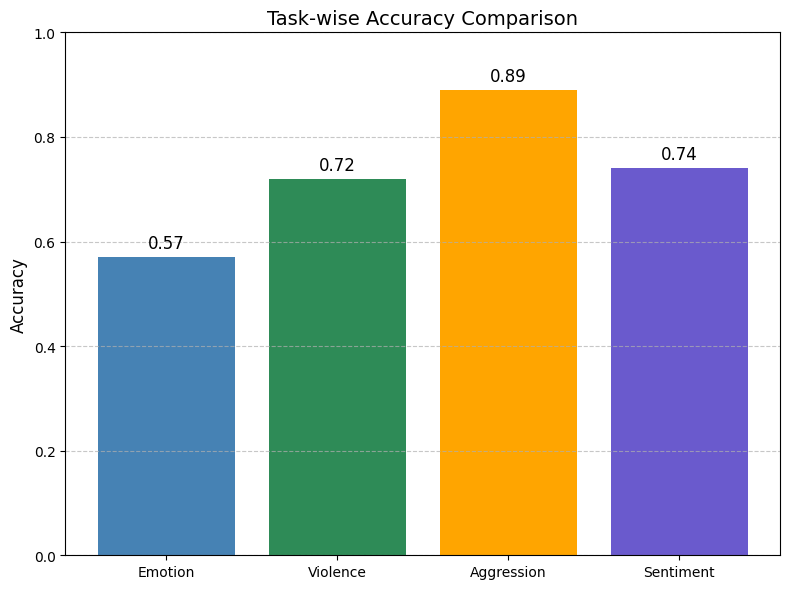

In [ ]:
import matplotlib.pyplot as plt

# Task names and their corresponding accuracies
tasks = ['Emotion', 'Violence', 'Aggression', 'Sentiment']
accuracies = [0.57, 0.72, 0.89, 0.74]

# Plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(tasks, accuracies, color=['steelblue', 'seagreen', 'orange', 'slateblue'])

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Formatting
plt.ylim(0, 1)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Task-wise Accuracy Comparison", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


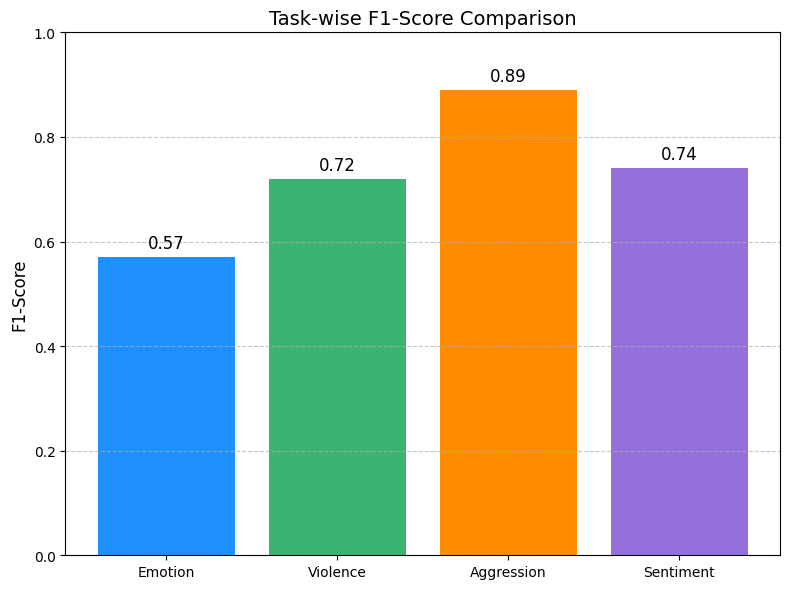

In [ ]:
import matplotlib.pyplot as plt

# Task names and F1-scores from your classification reports
tasks = ['Emotion', 'Violence', 'Aggression', 'Sentiment']
f1_scores = [0.57, 0.72, 0.89, 0.74]

# Plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(tasks, f1_scores, color=['dodgerblue', 'mediumseagreen', 'darkorange', 'mediumpurple'])

# Add F1-score values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Formatting
plt.ylim(0, 1)
plt.ylabel("F1-Score", fontsize=12)
plt.title("Task-wise F1-Score Comparison", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# ✅ Recreate test texts from the original DataFrames
emotion_test_texts = em_test_df['text'].tolist()
violence_test_texts = vi_test_df['text'].tolist()
aggression_test_texts = ag_test_df['text'].tolist()
sentiment_test_texts = snt_test_df['text'].tolist()

# ✅ Create DataFrames
emotion_result_df = pd.DataFrame({
    "Text": emotion_test_texts,
    "Actual Label": emotion_test_labels,
    "Predicted Label": test_preds_labels[0]
})

violence_result_df = pd.DataFrame({
    "Text": violence_test_texts,
    "Actual Label": violence_test_labels,
    "Predicted Label": test_preds_labels[1]
})

aggression_result_df = pd.DataFrame({
    "Text": aggression_test_texts,
    "Actual Label": aggressive_test_labels,
    "Predicted Label": test_preds_labels[2]
})

sentiment_result_df = pd.DataFrame({
    "Text": sentiment_test_texts,
    "Actual Label": sentiment_test_labels,
    "Predicted Label": test_preds_labels[2]
})

# ✅ Save to CSV files
emotion_result_df.to_csv("/content/emotion_test_results.csv", index=False)
violence_result_df.to_csv("/content/violence_test_results.csv", index=False)
aggression_result_df.to_csv("/content/aggression_test_results.csv", index=False)
sentiment_result_df.to_csv("/content/sentiment_test_results.csv", index=False)

print("✅ Test result datasets saved successfully!")


✅ Test result datasets saved successfully!


In [ ]:
# ✅ Calculate correct and incorrect counts for each task

# Emotion
emotion_correct = np.sum(emotion_test_labels == test_preds_labels[0])
emotion_total = len(emotion_test_labels)
emotion_wrong = emotion_total - emotion_correct

# Violence
violence_correct = np.sum(violence_test_labels == test_preds_labels[1])
violence_total = len(violence_test_labels)
violence_wrong = violence_total - violence_correct

# Aggression
aggression_correct = np.sum(aggressive_test_labels == test_preds_labels[2])
aggression_total = len(aggressive_test_labels)
aggression_wrong = aggression_total - aggression_correct

# Sentiment
sentiment_correct = np.sum(sentiment_test_labels == test_preds_labels[2])
sentiment_total = len(sentiment_test_labels)
sentiment_wrong = sentiment_total - sentiment_correct

# ✅ Print results
print("📊 Emotion Test Accuracy Stats:")
print(f"✅ Correct: {emotion_correct} | ❌ Wrong: {emotion_wrong} | Total: {emotion_total}\n")

print("📊 Violence Test Accuracy Stats:")
print(f"✅ Correct: {violence_correct} | ❌ Wrong: {violence_wrong} | Total: {violence_total}\n")

print("📊 Aggression Test Accuracy Stats:")
print(f"✅ Correct: {aggression_correct} | ❌ Wrong: {aggression_wrong} | Total: {aggression_total}")

print("📊 Sentiment Test Accuracy Stats:")
print(f"✅ Correct: {sentiment_correct} | ❌ Wrong: {sentiment_wrong} | Total: {sentiment_total}")


📊 Emotion Test Accuracy Stats:
✅ Correct: 354 | ❌ Wrong: 271 | Total: 625

📊 Violence Test Accuracy Stats:
✅ Correct: 437 | ❌ Wrong: 188 | Total: 625

📊 Aggression Test Accuracy Stats:
✅ Correct: 563 | ❌ Wrong: 62 | Total: 625
📊 Sentiment Test Accuracy Stats:
✅ Correct: 562 | ❌ Wrong: 63 | Total: 625


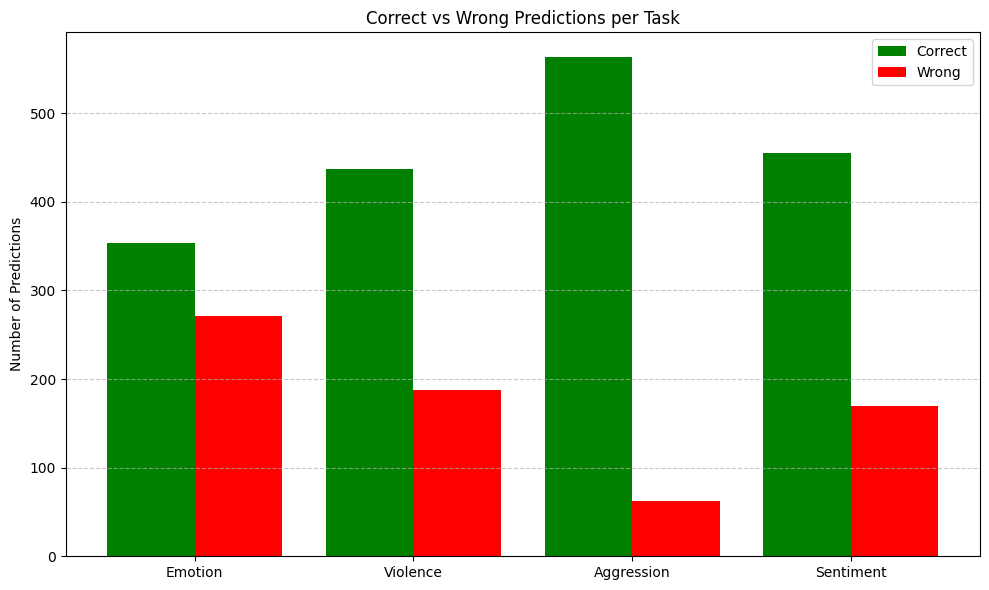

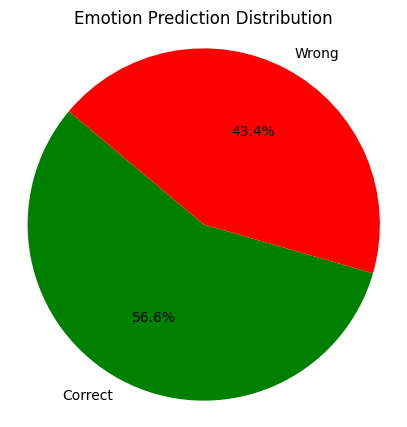

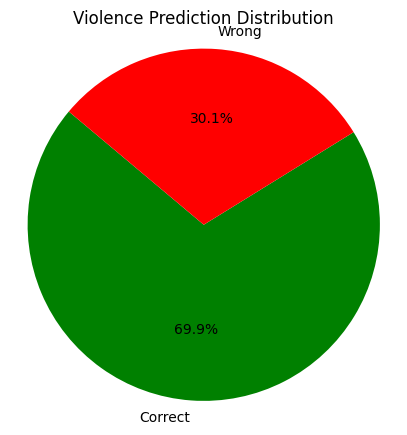

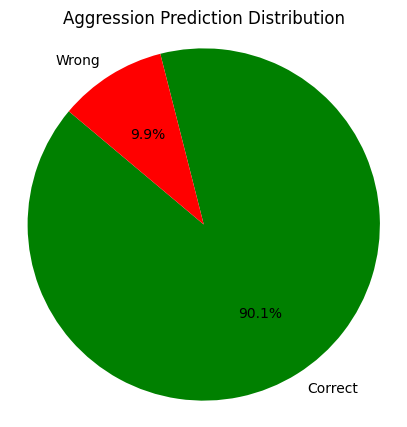

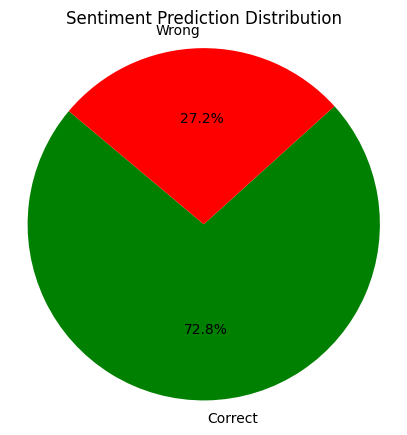

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ Store correct and wrong predictions
results = {
    "Emotion": {
        "correct": np.sum(emotion_test_labels == test_preds_labels[0]),
        "wrong": len(emotion_test_labels) - np.sum(emotion_test_labels == test_preds_labels[0])
    },
    "Violence": {
        "correct": np.sum(violence_test_labels == test_preds_labels[1]),
        "wrong": len(violence_test_labels) - np.sum(violence_test_labels == test_preds_labels[1])
    },
    "Aggression": {
        "correct": np.sum(aggressive_test_labels == test_preds_labels[2]),
        "wrong": len(aggressive_test_labels) - np.sum(aggressive_test_labels == test_preds_labels[2])
    },
    "Sentiment": {
        "correct": np.sum(sentiment_test_labels == test_preds_labels[3]),
        "wrong": len(sentiment_test_labels) - np.sum(sentiment_test_labels == test_preds_labels[3])
    }
}

# ✅ Bar Chart: Correct vs Wrong
plt.figure(figsize=(10, 6))
tasks = list(results.keys())
correct_vals = [results[t]['correct'] for t in tasks]
wrong_vals = [results[t]['wrong'] for t in tasks]

bar_width = 0.4
x = np.arange(len(tasks))

plt.bar(x - bar_width/2, correct_vals, width=bar_width, label='Correct', color='green')
plt.bar(x + bar_width/2, wrong_vals, width=bar_width, label='Wrong', color='red')
plt.xticks(x, tasks)
plt.ylabel("Number of Predictions")
plt.title("Correct vs Wrong Predictions per Task")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ✅ Pie Charts for each task
for task in tasks:
    labels = ['Correct', 'Wrong']
    sizes = [results[task]['correct'], results[task]['wrong']]
    colors = ['green', 'red']

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
    plt.axis('equal')
    plt.title(f"{task} Prediction Distribution")
    plt.show()


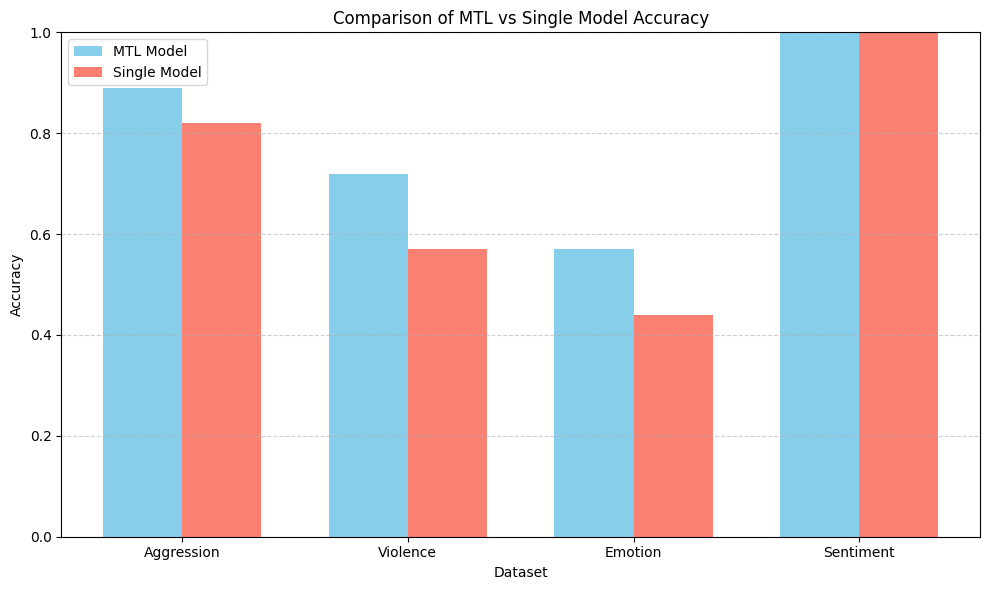

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset names
datasets = ['Aggression', 'Violence', 'Emotion', 'Sentiment']

# Accuracy values
mtl_accuracies = [0.89, 0.72, 0.57, 74]
single_accuracies = [0.82, 0.57, 0.44, 73]

# Bar width and positions
x = np.arange(len(datasets))
bar_width = 0.35

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width/2, mtl_accuracies, width=bar_width, label='MTL Model', color='skyblue')
plt.bar(x + bar_width/2, single_accuracies, width=bar_width, label='Single Model', color='salmon')

# Labels and title
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.title('Comparison of MTL vs Single Model Accuracy')
plt.xticks(x, datasets)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

# ✅ Plot Confusion Matrices for each task
plot_confusion(emotion_test_labels, test_preds_labels[0],
               labels=["joy", "sad", "surprise", "disgust", "anger", "fear"],
               title="Emotion Confusion Matrix")

plot_confusion(violence_test_labels, test_preds_labels[1],
               labels=["non-violent", "indirect", "direct"],
               title="Violence Confusion Matrix")

plot_confusion(aggressive_test_labels, test_preds_labels[2],
               labels=["non-aggressive", "aggressive"],
               title="Aggression Confusion Matrix")

plot_confusion(sentiment_test_labels, test_preds_labels[3],
               labels=["positive", "negative"],
               title="Sentiment Confusion Matrix")


# XLM ROBERTA

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Load model/tokenizer
xlmr_model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

# Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100
emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# Input Tensors
emotion_input = {'input_ids': emotion_encodings['input_ids'], 'attention_mask': emotion_encodings['attention_mask']}
violence_input = {'input_ids': violence_encodings['input_ids'], 'attention_mask': violence_encodings['attention_mask']}
aggressive_input = {'input_ids': aggressive_encodings['input_ids'], 'attention_mask': aggressive_encodings['attention_mask']}
sentiment_input = {'input_ids': sentiment_encodings['input_ids'], 'attention_mask': sentiment_encodings['attention_mask']}

emotion_eval_input = {'input_ids': emotion_eval_encodings['input_ids'], 'attention_mask': emotion_eval_encodings['attention_mask']}
violence_eval_input = {'input_ids': violence_eval_encodings['input_ids'], 'attention_mask': violence_eval_encodings['attention_mask']}
aggressive_eval_input = {'input_ids': aggressive_eval_encodings['input_ids'], 'attention_mask': aggressive_eval_encodings['attention_mask']}
sentiment_eval_input = {'input_ids': sentiment_eval_encodings['input_ids'], 'attention_mask': sentiment_eval_encodings['attention_mask']}

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

# Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ===== Custom Layers =====
class XLMRLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(XLMRLayer, self).__init__(**kwargs)
        self.model_name = model_name
        self.xlmr = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    def get_config(self):
        config = super().get_config()
        config.update({"model_name": self.model_name})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden):
    dense = Dense(1024, activation='relu')(hidden)
    return dense

# ===== Input Layers =====
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

xlmr_layer = XLMRLayer(model_name=xlmr_model_name)
attention_layer = AttentionLayer()

# ===== Emotion Branch =====
emotion_seq = xlmr_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ===== Violence Branch =====
violence_seq = xlmr_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ===== Aggression Branch =====
aggressive_seq = xlmr_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

#===== Sentiment Branch ====
sentiment_seq = xlmr_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ===== Build Model =====
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ===== Train =====
train_data = {
    'emotion_input_ids': emotion_input['input_ids'],
    'emotion_attention_mask': emotion_input['attention_mask'],
    'violence_input_ids': violence_input['input_ids'],
    'violence_attention_mask': violence_input['attention_mask'],
    'aggressive_input_ids': aggressive_input['input_ids'],
    'aggressive_attention_mask': aggressive_input['attention_mask'],
    'sentiment_input_ids': sentiment_input['input_ids'],
    'sentiment_attention_mask': sentiment_input['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ===== Save Model =====
model.save("/content/multi_task_xlmr_model_with_mha_ffn.keras")

# ===== Eval =====
eval_data = {
    'emotion_input_ids': emotion_eval_input['input_ids'],
    'emotion_attention_mask': emotion_eval_input['attention_mask'],
    'violence_input_ids': violence_eval_input['input_ids'],
    'violence_attention_mask': violence_eval_input['attention_mask'],
    'aggressive_input_ids': aggressive_eval_input['input_ids'],
    'aggressive_attention_mask': aggressive_eval_input['attention_mask'],
    'sentiment_input_ids': sentiment_eval_input['input_ids'],
    'sentiment_attention_mask': sentiment_eval_input['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ===== Test =====
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))



Num GPUs Available:  1


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.dense.bias', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.weight', 'lm_head.bias']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFXLMRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFXLMRobertaModel for predictions without further training.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 477s 309ms/step - aggressive_output_accuracy: 0.7390 - aggressive_output_loss: 0.5663 - emotion_output_accuracy: 0.2702 - emotion_output_loss: 1.8884 - loss: 4.4770 - sentiment_output_accuracy: 0.5705 - sentiment_output_loss: 0.7670 - violence_output_accuracy: 0.3963 - violence_output_loss: 1.2552
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 225s 311ms/step - aggressive_output_accuracy: 0.8959 - aggressive_output_loss: 0.2808 - emotion_output_accuracy: 0.4982 - emotion_output_loss: 1.2550 - loss: 2.9248 - sentiment_output_accuracy: 0.7626 - sentiment_output_loss: 0.5069 - violence_output_accuracy: 0.5933 - violence_output_loss: 0.8820
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 198s 293ms/step - aggressive_output_accuracy: 0.9117 - aggressive_output_loss: 0.2282 - emotion_output_accuracy: 0.5983 - emotion_output_loss: 1.0168 - loss: 2.4233 - sentiment_output_accuracy: 0.7893 - sentiment_output_loss: 0.4581 - violence_output_accuracy: 0.6844 - violence_out

# mBERT

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer for mBERT
mbert_model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100
emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MBERTLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MBERTLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

mbert_layer = MBERTLayer(model_name=mbert_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch
emotion_seq = mbert_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch
violence_seq = mbert_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch
aggressive_seq = mbert_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

#Sentiment Branch
sentiment_seq = mbert_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)


# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Train
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)
model.save("/content/mbert_multitask_model.keras")

# ✅ Evaluate on Validation Set
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Evaluate on Test Set
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))


Num GPUs Available:  1


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 133s 112ms/step - aggressive_output_accuracy: 0.7029 - aggressive_output_loss: 0.7403 - emotion_output_accuracy: 0.2255 - emotion_output_loss: 2.4845 - loss: 6.0902 - sentiment_output_accuracy: 0.5736 - sentiment_output_loss: 1.0678 - violence_output_accuracy: 0.4017 - violence_output_loss: 1.7976
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 123s 112ms/step - aggressive_output_accuracy: 0.8268 - aggressive_output_loss: 0.4129 - emotion_output_accuracy: 0.2852 - emotion_output_loss: 1.7836 - loss: 3.8301 - sentiment_output_accuracy: 0.6487 - sentiment_output_loss: 0.6426 - violence_output_accuracy: 0.5266 - violence_output_loss: 0.9909
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - aggressive_output_accuracy: 0.8599 - aggressive_output_loss: 0.3456 - emotion_output_accuracy: 0.3220 - emotion_output_loss: 1.6862 - loss: 3.4624 - sentiment_output_accuracy: 0.6963 - sentiment_output_loss: 0.5822 - violence_output_accuracy: 0.6296 - violence_outp

# INDIC BERT

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load IndicBERT
indicbert_model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(indicbert_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100
emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights for Violence
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class IndicBERTLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(IndicBERTLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name, from_pt=True)  # ✅ FIXED

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')


indic_layer = IndicBERTLayer(model_name=indicbert_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch
emotion_seq = indic_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch
violence_seq = indic_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch
aggressive_seq = indic_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

#Sentiment Branch
sentiment_seq = indic_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Train Model
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)
model.save("/content/indicbert_multitask_model.keras")

# ✅ Evaluation - Validation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Evaluation - Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))


Num GPUs Available:  1


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFAlbertModel: ['predictions.dense.weight', 'predictions.LayerNorm.weight', 'sop_classifier.classifier.weight', 'predictions.bias', 'predictions.LayerNorm.bias', 'predictions.decoder.weight', 'predictions.decoder.bias', 'predictions.dense.bias', 'sop_classifier.classifier.bias']
- This IS expected if you are initializing TFAlbertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFAlbertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFAlbertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFAlbertModel

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 129s 111ms/step - aggressive_output_accuracy: 0.6343 - aggressive_output_loss: 0.9605 - emotion_output_accuracy: 0.2087 - emotion_output_loss: 2.2959 - loss: 6.2715 - sentiment_output_accuracy: 0.5228 - sentiment_output_loss: 1.2043 - violence_output_accuracy: 0.3381 - violence_output_loss: 1.8109
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 72s 107ms/step - aggressive_output_accuracy: 0.7292 - aggressive_output_loss: 0.5365 - emotion_output_accuracy: 0.3265 - emotion_output_loss: 1.8259 - loss: 4.0970 - sentiment_output_accuracy: 0.5781 - sentiment_output_loss: 0.6895 - violence_output_accuracy: 0.4409 - violence_output_loss: 1.0451
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - aggressive_output_accuracy: 0.7866 - aggressive_output_loss: 0.4704 - emotion_output_accuracy: 0.4436 - emotion_output_loss: 1.4553 - loss: 3.5670 - sentiment_output_accuracy: 0.6362 - sentiment_output_loss: 0.6426 - violence_output_accuracy: 0.5138 - violence_outpu

# BANGLA BERT

In [ ]:
from re import S
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# Load BanglaBERT
banglabert_model_name = "csebuetnlp/banglabert_large"
tokenizer = AutoTokenizer.from_pretrained(banglabert_model_name)
print("✅ Loaded BanglaBERT")

# Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv("/content/snt_balanced_dev.csv")

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv("/content/snt_balanced_test.csv")

# Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100
emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_val_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_val_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_val_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_val_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# Class weights for violence
violence_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
violence_class_weights_dict = {i: violence_class_weights[i] for i in range(len(violence_class_weights))}

def custom_weighted_loss(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather(list(class_weights.values()), y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# Custom BanglaBERT Layer
class BanglaBERTLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(BanglaBERTLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name, from_pt=True)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

# Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, hidden_size=1024):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(hidden_size)(dense)
    return proj

# Input creation helper
def create_input(name):
    return (
        Input(shape=(max_length,), dtype=tf.int32, name=f'{name}_input_ids'),
        Input(shape=(max_length,), dtype=tf.int32, name=f'{name}_attention_mask')
    )

# Create Inputs
emotion_input_ids, emotion_attention_mask = create_input('emotion')
violence_input_ids, violence_attention_mask = create_input('violence')
aggressive_input_ids, aggressive_attention_mask = create_input('aggressive')
sentiment_input_ids, sentiment_attention_mask = create_input('sentiment')

bert_layer = BanglaBERTLayer(model_name=banglabert_model_name)
attention_layer = AttentionLayer()

# Task branch function with explicit naming of output layer
def task_branch(input_ids, attention_mask, output_dim, name):
    seq = bert_layer([input_ids, attention_mask])
    mha = MultiHeadAttention(num_heads=8, key_dim=128)(seq, seq)
    mha_norm = LayerNormalization(epsilon=1e-6)(mha + seq)
    ffn = ffn_layer(mha_norm, hidden_size=1024)
    ffn_norm = LayerNormalization(epsilon=1e-6)(ffn + mha_norm)
    att = attention_layer(ffn_norm)
    return Dense(output_dim, activation='softmax', name=name)(att)

# Create output layers with correct names
emotion_output = task_branch(emotion_input_ids, emotion_attention_mask, 6, name="emotion_output")
violence_output = task_branch(violence_input_ids, violence_attention_mask, 3, name="violence_output")
aggressive_output = task_branch(aggressive_input_ids, aggressive_attention_mask, 2, name="aggression_output")
sentiment_output = task_branch(sentiment_input_ids, sentiment_attention_mask, 2, name="sentiment_output")

# Build model
model = Model(
    inputs=[
        emotion_input_ids, emotion_attention_mask,
        violence_input_ids, violence_attention_mask,
        aggressive_input_ids, aggressive_attention_mask,
        sentiment_input_ids, sentiment_attention_mask
    ],
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# Compile model with matching loss and metrics names
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': custom_weighted_loss(violence_class_weights_dict),
        'aggression_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggression_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggression_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# Prepare inputs dictionary
train_inputs = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggression_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# Train
model.fit(train_inputs, train_labels, epochs=8, batch_size=4)

# Save model
model.save("/content/banglabert_multitask_model_fixed.keras")

from sklearn.metrics import classification_report

# Prepare test inputs dictionary
test_inputs = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

# True labels
test_labels = {
    'emotion_output': emotion_test_labels,
    'violence_output': violence_test_labels,
    'aggression_output': aggressive_test_labels,
    'sentiment_output': sentiment_test_labels
}

# Predict on test set
preds = model.predict(test_inputs, batch_size=4)

# preds is a list of numpy arrays [emotion_preds, violence_preds, aggression_preds]
# Convert softmax outputs to class predictions (argmax)
emotion_pred_labels = np.argmax(preds[0], axis=1)
violence_pred_labels = np.argmax(preds[1], axis=1)
aggression_pred_labels = np.argmax(preds[2], axis=1)
sentiment_pred_labels = np.argmax(preds[3], axis=1)

# Print classification reports for each task
print("Emotion Classification Report:")
print(classification_report(test_labels['emotion_output'], emotion_pred_labels))

print("Violence Classification Report:")
print(classification_report(test_labels['violence_output'], violence_pred_labels))

print("Aggression Classification Report:")
print(classification_report(test_labels['aggression_output'], aggression_pred_labels))

print("Sentiment Classification Report:")
print(classification_report(test_labels['sentiment_output'], sentiment_pred_labels))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Loaded BanglaBERT


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFElectraModel: ['discriminator_predictions.dense.bias', 'discriminator_predictions.dense_prediction.weight', 'discriminator_predictions.dense.weight', 'discriminator_predictions.dense_prediction.bias', 'electra.embeddings.position_ids']
- This IS expected if you are initializing TFElectraModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFElectraModel from a PyTorch model that you expect to be exactly identical (

Epoch 1/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 351s 368ms/step - aggression_output_accuracy: 0.6698 - aggression_output_loss: 0.6027 - emotion_output_accuracy: 0.2006 - emotion_output_loss: 1.8405 - loss: 4.3239 - sentiment_output_accuracy: 0.5539 - sentiment_output_loss: 0.7117 - violence_output_accuracy: 0.3395 - violence_output_loss: 1.1688
Epoch 2/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 283s 365ms/step - aggression_output_accuracy: 0.7707 - aggression_output_loss: 0.4965 - emotion_output_accuracy: 0.2883 - emotion_output_loss: 1.6885 - loss: 3.9358 - sentiment_output_accuracy: 0.6204 - sentiment_output_loss: 0.6621 - violence_output_accuracy: 0.4259 - violence_output_loss: 1.0887
Epoch 3/8
675/675 ━━━━━━━━━━━━━━━━━━━━ 262s 365ms/step - aggression_output_accuracy: 0.7756 - aggression_output_loss: 0.4591 - emotion_output_accuracy: 0.3564 - emotion_output_loss: 1.5878 - loss: 3.7090 - sentiment_output_accuracy: 0.6483 - sentiment_output_loss: 0.6304 - violence_output_accuracy: 0.4719 - violence_output